# Robi only — all 13 forecasting models


## 1. Packages


In [4]:
import hashlib
import importlib.util
import json
import os
import random
import subprocess
import sys
import time
import warnings
import zipfile
from pathlib import Path
from importlib.metadata import version

needed = {'lightgbm': 'lightgbm', 'xgboost': 'xgboost', 'catboost': 'catboost',
          'statsmodels': 'statsmodels', 'openpyxl': 'openpyxl'}
missing = [package for module, package in needed.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor, early_stopping
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore')

print('Packages ready.')

Packages ready.


## 2. Settings


In [5]:
mode = 'Robi'
operators = ['GP', 'Robi'] if mode == 'Combined' else [mode]
run_name = {'GP': 'GP_only', 'Robi': 'Robi_only', 'Combined': 'Ensembled'}[mode]
train_label = {'GP': 'GP only', 'Robi': 'Robi only', 'Combined': 'GP + Robi (pooled)'}[mode]

kaggle_input = Path('/kaggle/input')
if Path('/kaggle/working').exists():
    output_root = Path('/kaggle/working') / 'final_model_results'
elif Path('/content/drive/MyDrive/Project').exists():
    output_root = Path('/content/drive/MyDrive/Project') / 'final_model_results'
else:
    output_root = Path.cwd() / 'final_model_results'
output_dir = output_root / run_name
output_dir.mkdir(parents=True, exist_ok=True)

interval = pd.Timedelta(hours=2)
valid_start = pd.Timestamp('2025-05-13 12:00:00')
test_start = pd.Timestamp('2025-05-23 12:00:00')
lags = [1, 2, 3, 12, 24]
planned_flags = ['holiday', 'offer', 'political_gathering', 'event']
observed_flags = ['rain', 'powercut']
roll_windows = [5, 12, 19, 24]
lookback = 24
seeds = [1, 2, 3, 4, 5]
tuning_seeds = [1, 2, 3]
max_epochs = 200
patience = 20
batch_size = 32

random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass
print('Mode:', mode, '| validation from', valid_start, '| test from', test_start)

# This is a service preference, not a guaranteed future coverage level.
allocation_quantile = 0.95
diagnostic_band_level = 0.90
forecast_tolerance_pct = 5.0


Mode: Robi | validation from 2025-05-13 12:00:00 | test from 2025-05-23 12:00:00


### Embedded Excel payloads


In [6]:
import base64
import io

# Exact supplied Excel bytes, embedded for offline input loading.
# The harmonized reference is not used as a raw-Gbps training target.
EMBEDDED_WORKBOOKS = {
    'Robi': {
        'filename': 'Robi_Updated_Features.xlsx',
        'sha256': 'c23616fc9bf33fc4d2a74d1b54fbf25502c987dbc22f9ab74bfcf6893b46cc49',
        'base64': (
            '...'
        ),
    },
}

def embedded_excel_bytes(key):
    entry = EMBEDDED_WORKBOOKS[key]
    payload = base64.b64decode(entry['base64'], validate=True)
    digest = hashlib.sha256(payload).hexdigest()
    if digest != entry['sha256']:
        raise ValueError(f"Embedded workbook checksum mismatch: {entry['filename']}")
    return payload

print('Embedded raw training data:', ', '.join(operators))
if 'Harmonized_reference' in EMBEDDED_WORKBOOKS:
    print('Harmonized Combined workbook is embedded as reference only; training uses raw GP and Robi Gbps.')


Embedded raw training data: Robi


## 3. Load the data


In [7]:
flag_columns = planned_flags + observed_flags

def load_raw(operator):
    entry = EMBEDDED_WORKBOOKS[operator]
    payload = embedded_excel_bytes(operator)
    data = pd.read_excel(io.BytesIO(payload), sheet_name=0)
    data = data[['Timestamp', 'Gbps'] + [c for c in flag_columns if c in data]].copy()
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    data['Gbps'] = pd.to_numeric(data['Gbps'])
    data = data.sort_values('Timestamp').set_index('Timestamp')
    assert not data.index.has_duplicates, f'{operator}: repeated timestamps'
    assert (data.index.to_series().diff().dropna() == interval).all(), f'{operator}: gaps in the 2-hour grid'
    assert data['Gbps'].notna().all() and (data['Gbps'] >= 0).all(), f'{operator}: missing or negative Gbps'
    assert len(data) == 733, f'{operator}: expected 733 supplied observations'
    for column in flag_columns:
        data[column] = pd.to_numeric(data[column], errors='coerce') if column in data else np.nan
    receipt = {'file': entry['filename'], 'sha256': entry['sha256'],
               'rows': len(data), 'source': 'embedded original Excel bytes',
               'target_column': 'Gbps', 'target_unit': 'Gbps'}
    return data, receipt

raw, sources = {}, {}
for operator in operators:
    raw[operator], sources[operator] = load_raw(operator)
if mode == 'Combined':
    assert raw['GP'].index.equals(raw['Robi'].index), 'GP and Robi timestamps must match'

overview = []
for operator, data in raw.items():
    index = data.index
    overview.append({'operator': operator, 'rows': len(data), 'first': index.min(), 'last': index.max(),
                     'validation_rows': int(((index >= valid_start) & (index < test_start)).sum()),
                     'test_rows': int((index >= test_start).sum())})
overview = pd.DataFrame(overview)
assert (overview.validation_rows == 120).all() and (overview.test_rows == 120).all()
display(overview)

,operator,rows,first,last,validation_rows,test_rows
0,Robi,733,2025-04-02 10:00:00,2025-06-02 10:00:00,120,120


## 4. Features (all causal)


In [8]:
def engineer(data):
    out = pd.DataFrame(index=data.index)
    traffic = data['Gbps']
    for n in lags:
        out[f'lag_{n}'] = traffic.shift(n)
    for n in roll_windows:
        past = traffic.shift(1).rolling(n, min_periods=n)
        out[f'rolling_mean_{n}'] = past.mean()
        out[f'rolling_std_{n}'] = past.std()
    out['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    out['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    out['weekday_sin'] = np.sin(2 * np.pi * data.index.dayofweek / 7)
    out['weekday_cos'] = np.cos(2 * np.pi * data.index.dayofweek / 7)
    out['weekend'] = data.index.dayofweek.isin([4, 5]).astype(float)
    for column in planned_flags:
        out[column + '_today'] = data[column]
        out[column + '_missing'] = data[column].isna().astype(float)
    for column in observed_flags:
        out[column + '_yesterday'] = data[column].shift(12)
        out[column + '_missing'] = out[column + '_yesterday'].isna().astype(float)
    return out

engineered = {operator: engineer(data) for operator, data in raw.items()}
base_features = engineered[operators[0]].columns.tolist()
traffic_features = [c for c in base_features if c.startswith(('lag_', 'rolling_'))]
operator_features = ['operator_GP', 'operator_Robi'] if mode == 'Combined' else []
feature_names = base_features + operator_features

for operator, data in raw.items():
    f = engineered[operator]
    for n in lags:
        np.testing.assert_allclose(f[f'lag_{n}'].iloc[n:].to_numpy(), data['Gbps'].iloc[:-n].to_numpy())
    for cut in [valid_start, test_start, data.index[-1]]:
        position = data.index.get_loc(cut)
        changed = data.copy()
        changed.iloc[position:, changed.columns.get_loc('Gbps')] += 10000
        for column in observed_flags:
            changed.iloc[position:, changed.columns.get_loc(column)] = 1.0
        pd.testing.assert_frame_equal(f.iloc[:position + 1], engineer(changed).iloc[:position + 1])
        same_day = data.index.normalize() == cut.normalize()
        flipped = data.copy()
        for column in observed_flags:
            flipped.loc[same_day, column] = 1 - flipped.loc[same_day, column].fillna(0)
        pd.testing.assert_frame_equal(f.loc[same_day], engineer(flipped).loc[same_day])
print(len(feature_names), 'features:', feature_names)
print('Causality check 1 passed: changing traffic, rain or power-cut from a time onward never changes the features at that time or earlier.')
print("Causality check 2 passed: flipping a whole day's rain and power-cut labels never changes that same day's features.")

30 features: ['lag_1', 'lag_2', 'lag_3', 'lag_12', 'lag_24', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_19', 'rolling_std_19', 'rolling_mean_24', 'rolling_std_24', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'weekend', 'holiday_today', 'holiday_missing', 'offer_today', 'offer_missing', 'political_gathering_today', 'political_gathering_missing', 'event_today', 'event_missing', 'rain_yesterday', 'rain_missing', 'powercut_yesterday', 'powercut_missing']
Causality check 1 passed: changing traffic, rain or power-cut from a time onward never changes the features at that time or earlier.
Causality check 2 passed: flipping a whole day's rain and power-cut labels never changes that same day's features.


## 5. Samples, splits and scaling


In [9]:
first_target = {}
for operator in operators:
    complete = engineered[operator][traffic_features].notna().all(axis=1).to_numpy()
    usable = np.array([i >= lookback - 1 and complete[i - lookback + 1:i + 1].all() for i in range(len(complete))])
    first_target[operator] = int(np.flatnonzero(usable)[0])
    assert usable[first_target[operator]:].all()

target_scalers = {}
for operator in operators:
    traffic = raw[operator]['Gbps'].iloc[first_target[operator]:]
    train_traffic = traffic.loc[traffic.index < valid_start]
    target_scalers[operator] = {'mean': float(train_traffic.mean()), 'std': float(train_traffic.std(ddof=0))}

def scale_traffic_columns(operator):
    values = engineered[operator].copy()
    mean, std = target_scalers[operator]['mean'], target_scalers[operator]['std']
    for column in traffic_features:
        values[column] = values[column] / std if column.startswith('rolling_std_') else (values[column] - mean) / std
    return values

scaled = {operator: scale_traffic_columns(operator) for operator in operators}
train_rows = pd.concat([scaled[op].iloc[first_target[op]:].loc[lambda d: d.index < valid_start] for op in operators])
medians = train_rows.median().fillna(0.0)
feature_scaler = StandardScaler().fit(train_rows.fillna(medians))

tables, sequences, targets, rows = [], [], [], []
for operator in operators:
    values = feature_scaler.transform(scaled[operator].fillna(medians)).astype(np.float32)
    if mode == 'Combined':
        flag = np.array([float(operator == 'GP'), float(operator == 'Robi')], dtype=np.float32)
        values = np.column_stack([values, np.tile(flag, (len(values), 1))]).astype(np.float32)
    traffic = raw[operator]['Gbps']
    scaler = target_scalers[operator]
    for i in range(first_target[operator], len(values)):
        timestamp = traffic.index[i]
        split = 'train' if timestamp < valid_start else 'validation' if timestamp < test_start else 'test'
        tables.append(values[i])
        sequences.append(values[i - lookback + 1:i + 1])
        targets.append((traffic.iloc[i] - scaler['mean']) / scaler['std'])
        rows.append({'Timestamp': timestamp, 'operator': operator, 'split': split,
                     'position': i, 'actual_Gbps': float(traffic.iloc[i])})

meta = pd.DataFrame(rows)
order = meta.sort_values(['Timestamp', 'operator'], kind='stable').index.to_numpy()
meta = meta.iloc[order].reset_index(drop=True)
x_tab = np.asarray(tables, dtype=np.float32)[order]
x_seq = np.asarray(sequences, dtype=np.float32)[order]
y = np.asarray(targets, dtype=np.float32)[order]
actual = meta.actual_Gbps.to_numpy()
row_mean = meta.operator.map(lambda op: target_scalers[op]['mean']).to_numpy()
row_std = meta.operator.map(lambda op: target_scalers[op]['std']).to_numpy()

train_mask = meta.split.eq('train').to_numpy()
val_mask = meta.split.eq('validation').to_numpy()
test_mask = meta.split.eq('test').to_numpy()
final_mask = train_mask | val_mask

assert np.isfinite(x_tab).all() and np.isfinite(x_seq).all() and np.isfinite(y).all()
assert not meta.duplicated(['Timestamp', 'operator']).any()
for operator in operators:
    own = meta.operator.eq(operator).to_numpy()
    assert (val_mask & own).sum() == 120 and (test_mask & own).sum() == 120
    expected = raw[operator].index[raw[operator].index >= test_start]
    assert pd.DatetimeIndex(meta.loc[test_mask & own, 'Timestamp']).equals(expected)
np.testing.assert_array_equal(x_seq[:, -1, :], x_tab)

split_table = meta.groupby(['operator', 'split']).Timestamp.agg(['count', 'min', 'max']).reindex(
    ['train', 'validation', 'test'], level=1)
display(split_table)
print('Table shape:', x_tab.shape, '| sequence shape:', x_seq.shape)

count                 min                 max
operator split                                                    
Robi     train         446 2025-04-06 08:00:00 2025-05-13 10:00:00
         validation    120 2025-05-13 12:00:00 2025-05-23 10:00:00
         test          120 2025-05-23 12:00:00 2025-06-02 10:00:00

Table shape: (686, 30) | sequence shape: (686, 24, 30)


## 6. Helpers


In [10]:
def to_gbps(z, mask):
    return np.asarray(z, dtype=float).ravel() * row_std[mask] + row_mean[mask]

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))

tuning_rows, selected, validation_predictions = [], {}, {}

def record(model, config, prediction, budget=None):
    prediction = np.asarray(prediction, dtype=float).ravel()
    assert len(prediction) == val_mask.sum() and np.isfinite(prediction).all()
    row = {'model': model, 'candidate': config['id'],
           'validation_RMSE_Gbps': rmse(actual[val_mask], prediction)}
    for operator in operators:
        own = meta.operator[val_mask].eq(operator).to_numpy()
        row[f'{operator}_RMSE_Gbps'] = rmse(actual[val_mask][own], prediction[own])
    row['budget'] = budget
    tuning_rows.append(row)
    validation_predictions[(model, config['id'])] = prediction
    print(f"{model:14s} {config['id']:30s} validation RMSE {row['validation_RMSE_Gbps']:.3f}", flush=True)

def choose(model, configs):
    table = pd.DataFrame([r for r in tuning_rows if r['model'] == model])
    best = table.loc[table.validation_RMSE_Gbps.idxmin()]
    chosen = dict(next(c for c in configs if c['id'] == best.candidate))
    chosen['budget'] = None if pd.isna(best.budget) else int(best.budget)
    chosen['validation_RMSE_Gbps'] = float(best.validation_RMSE_Gbps)
    selected[model] = chosen
    print('Selected', model, '->', chosen['id'], flush=True)
    return chosen

flag_indices = [i for i, c in enumerate(feature_names) if c.endswith(('_today', '_yesterday', '_missing'))]
feature_sets = {'all': list(range(len(feature_names))),
                'no_flags': [i for i in range(len(feature_names)) if i not in flag_indices]}

def fit_window(operator, end, history=0):
    series = raw[operator]['Gbps'].asfreq(interval)
    part = series.iloc[first_target[operator] - history:]
    return part.loc[part.index < end]

def training_timestamps(operator, end):
    own = meta.operator.eq(operator).to_numpy() & (meta.Timestamp < end).to_numpy()
    return pd.DatetimeIndex(meta.loc[own, 'Timestamp'])

def pick(series_by_operator, mask):
    part = meta.loc[mask].reset_index(drop=True)
    out = np.empty(len(part))
    for operator in operators:
        own = part.operator.eq(operator).to_numpy()
        out[own] = series_by_operator[operator].reindex(pd.DatetimeIndex(part.loc[own, 'Timestamp'])).to_numpy()
    assert np.isfinite(out).all()
    return out

same_data = []
for operator in operators:
    own = meta.operator.eq(operator).to_numpy()
    for label, mask in [('train (tuning)', train_mask), ('validation', val_mask),
                        ('train + validation (final fit)', final_mask), ('test', test_mask)]:
        stamps = meta.loc[mask & own, 'Timestamp']
        same_data.append({'operator': operator, 'part': label, 'rows': len(stamps),
                          'first': stamps.min(), 'last': stamps.max()})
same_data = pd.DataFrame(same_data)
display(same_data)

,operator,part,rows,first,last
0,Robi,train (tuning),446,2025-04-06 08:00:00,2025-05-13 10:00:00
1,Robi,validation,120,2025-05-13 12:00:00,2025-05-23 10:00:00
2,Robi,train + validation (final fit),566,2025-04-06 08:00:00,2025-05-23 10:00:00
3,Robi,test,120,2025-05-23 12:00:00,2025-06-02 10:00:00


## 7. Model code


In [11]:
def tab(mask, config):
    return x_tab[mask][:, feature_sets[config['features']]]

def fit_ridge(config, fit_mask, rounds=None):
    return Ridge(alpha=config['alpha']).fit(tab(fit_mask, config), y[fit_mask]), None

def fit_lightgbm(config, fit_mask, rounds=None):
    model = LGBMRegressor(n_estimators=rounds or 3000, learning_rate=config['learning_rate'],
                          max_depth=config['max_depth'], num_leaves=config['num_leaves'],
                          min_child_samples=config['min_child_samples'], reg_lambda=config['reg_lambda'],
                          subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                          random_state=42, n_jobs=2, verbosity=-1)
    if rounds:
        return model.fit(tab(fit_mask, config), y[fit_mask]), rounds
    model.fit(tab(fit_mask, config), y[fit_mask], eval_set=[(tab(val_mask, config), y[val_mask])],
              callbacks=[early_stopping(100, verbose=False)])
    return model, int(model.best_iteration_)

def fit_xgboost(config, fit_mask, rounds=None):
    settings = dict(n_estimators=rounds or 3000, learning_rate=config['learning_rate'],
                    max_depth=config['max_depth'], min_child_weight=config['min_child_weight'],
                    reg_lambda=config['reg_lambda'], subsample=0.85, colsample_bytree=0.85,
                    objective='reg:squarederror', random_state=42, n_jobs=2)
    if rounds:
        return XGBRegressor(**settings).fit(tab(fit_mask, config), y[fit_mask]), rounds
    model = XGBRegressor(early_stopping_rounds=100, eval_metric='rmse', **settings)
    model.fit(tab(fit_mask, config), y[fit_mask], eval_set=[(tab(val_mask, config), y[val_mask])], verbose=False)
    return model, int(model.best_iteration + 1)

def fit_catboost(config, fit_mask, rounds=None):
    settings = dict(iterations=rounds or 3000, learning_rate=config['learning_rate'], depth=config['depth'],
                    l2_leaf_reg=config['l2_leaf_reg'], loss_function='RMSE', random_seed=42,
                    thread_count=2, verbose=0, allow_writing_files=False)
    if rounds:
        return CatBoostRegressor(**settings).fit(tab(fit_mask, config), y[fit_mask]), rounds
    model = CatBoostRegressor(od_type='Iter', od_wait=100, use_best_model=True, **settings)
    model.fit(tab(fit_mask, config), y[fit_mask], eval_set=(tab(val_mask, config), y[val_mask]))
    return model, int(model.get_best_iteration() + 1)

def predict_tabular(model, config, mask):
    return to_gbps(model.predict(tab(mask, config)), mask)

tabular_functions = {'Ridge': fit_ridge, 'LightGBM': fit_lightgbm, 'XGBoost': fit_xgboost, 'CatBoost': fit_catboost}

operator_indices = [feature_names.index(c) for c in operator_features]
channel_sets = {'traffic': ['lag_1'], 'traffic_hour': ['lag_1', 'hour_sin', 'hour_cos']}

def neural_input(config):
    columns = [feature_names.index(c) for c in channel_sets[config['channels']]] + operator_indices
    return x_seq[:, -config['window']:, columns]

def build_network(model_name, shape, config):
    layers = [keras.layers.Input(shape=shape)]
    if model_name == 'LSTM':
        layers.append(keras.layers.LSTM(config['units']))
    elif model_name == 'SimpleRNN':
        layers.append(keras.layers.SimpleRNN(config['units']))
    elif model_name == 'GRU':
        layers.append(keras.layers.GRU(config['units']))
    elif model_name == 'CNN':
        layers += [keras.layers.Conv1D(config['filters'], 3, activation='relu'), keras.layers.Flatten(),
                   keras.layers.Dense(config['units'], activation='relu')]
    elif model_name == 'CNN+SimpleRNN':
        layers += [keras.layers.Conv1D(config['filters'], 3, activation='relu'),
                   keras.layers.SimpleRNN(config['units'])]
    if config.get('dropout'):
        layers.append(keras.layers.Dropout(config['dropout']))
    layers.append(keras.layers.Dense(1))
    net = keras.Sequential(layers)
    net.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss='mse')
    return net

def train_network(model_name, config, fit_mask, seed, epochs=None):
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    x = neural_input(config)
    net = build_network(model_name, x.shape[1:], config)
    if epochs:
        net.fit(x[fit_mask], y[fit_mask], epochs=epochs, batch_size=batch_size, shuffle=True, verbose=0)
        return net, epochs
    stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    history = net.fit(x[fit_mask], y[fit_mask], validation_data=(x[val_mask], y[val_mask]),
                      epochs=max_epochs, batch_size=batch_size, shuffle=True, verbose=0, callbacks=[stop])
    return net, int(np.argmin(history.history['val_loss']) + 1)

def predict_network(net, config, mask):
    return to_gbps(net.predict(neural_input(config)[mask], batch_size=256, verbose=0), mask)

def ar_series(operator, config, end):
    order = config['order']
    window = fit_window(operator, end, history=order)
    assert window.index[order:].equals(training_timestamps(operator, end))
    coefficients = np.asarray(AutoReg(window.to_numpy(), lags=order).fit().params)
    values = raw[operator]['Gbps'].to_numpy()
    start = first_target[operator]
    lagged = np.column_stack([values[start - k:len(values) - k] for k in range(1, order + 1)])
    return pd.Series(coefficients[0] + lagged @ coefficients[1:], index=raw[operator].index[start:])

def arima_series(operator, config, end):
    window = fit_window(operator, end)
    assert window.index.equals(training_timestamps(operator, end))
    spec = dict(order=tuple(config['order']), seasonal_order=tuple(config['seasonal_order']))
    fitted = ARIMA(window.to_numpy(), **spec).fit()
    full = raw[operator]['Gbps'].iloc[first_target[operator]:]
    return pd.Series(np.asarray(fitted.apply(full.to_numpy()).fittedvalues), index=full.index)

def hw_series(operator, config, end):
    window = fit_window(operator, end)
    assert window.index.equals(training_timestamps(operator, end))
    spec = dict(trend=config['trend'], seasonal=config['seasonal'], damped_trend=config['damped'],
                seasonal_periods=config['period'])
    fitted = ExponentialSmoothing(window, initialization_method='estimated', **spec).fit(optimized=True)
    p = fitted.params
    initial = dict(initial_level=p['initial_level'], initial_seasonal=p['initial_seasons'])
    smoothing = dict(smoothing_level=p['smoothing_level'], smoothing_seasonal=p['smoothing_seasonal'])
    if config['trend']:
        initial['initial_trend'] = p['initial_trend']
        smoothing['smoothing_trend'] = p['smoothing_trend']
    if config['damped']:
        smoothing['damping_trend'] = p['damping_trend']
    full = raw[operator]['Gbps'].asfreq(interval).iloc[first_target[operator]:]
    filtered = ExponentialSmoothing(full, initialization_method='known', **spec, **initial).fit(
        optimized=False, **smoothing)
    np.testing.assert_allclose(filtered.fittedvalues.loc[window.index], fitted.fittedvalues, rtol=1e-6, atol=1e-6)
    return filtered.fittedvalues

stat_functions = {'AR': ar_series, 'ARIMA': arima_series, 'Holt-Winters': hw_series}

def for_operator(config, operator):
    return config['per_operator'][operator] if 'per_operator' in config else config

def stat_fit(model_name, config, end):
    return {operator: stat_functions[model_name](operator, for_operator(config, operator), end)
            for operator in operators}
print('Model functions ready.')

Model functions ready.


## 8. Baseline: persistence


In [12]:
def persistence(mask):
    return pick({operator: raw[operator]['Gbps'].shift(1) for operator in operators}, mask)

record('Persistence', {'id': 'previous_value'}, persistence(val_mask))
selected['Persistence'] = {'id': 'previous_value', 'budget': None,
                           'validation_RMSE_Gbps': tuning_rows[-1]['validation_RMSE_Gbps']}

Persistence    previous_value                 validation RMSE 30.146


## 9. Tune Ridge, LightGBM, XGBoost and CatBoost


In [13]:
tabular_configs = {
    'Ridge': [
        dict(id='alpha_1_all', features='all', alpha=1),
        dict(id='alpha_3_all', features='all', alpha=3),
        dict(id='alpha_10_all', features='all', alpha=10),
        dict(id='alpha_3_no_flags', features='no_flags', alpha=3),
        dict(id='alpha_10_no_flags', features='no_flags', alpha=10),
        dict(id='alpha_30_no_flags', features='no_flags', alpha=30)],
    'LightGBM': [
        dict(id='depth3_leaves7_child10_all', features='all', learning_rate=0.03, max_depth=3,
             num_leaves=7, min_child_samples=10, reg_lambda=1),
        dict(id='depth4_leaves7_child10_all', features='all', learning_rate=0.03, max_depth=4,
             num_leaves=7, min_child_samples=10, reg_lambda=1),
        dict(id='depth6_leaves7_child10_all', features='all', learning_rate=0.03, max_depth=6,
             num_leaves=7, min_child_samples=10, reg_lambda=10),
        dict(id='depth6_leaves15_child10_all', features='all', learning_rate=0.03, max_depth=6,
             num_leaves=15, min_child_samples=10, reg_lambda=10),
        dict(id='depth4_leaves7_child40_no_flags', features='no_flags', learning_rate=0.03, max_depth=4,
             num_leaves=7, min_child_samples=40, reg_lambda=10),
        dict(id='depth6_leaves15_child40_no_flags', features='no_flags', learning_rate=0.03, max_depth=6,
             num_leaves=15, min_child_samples=40, reg_lambda=1)],
    'XGBoost': [
        dict(id='depth2_child1_all', features='all', learning_rate=0.03, max_depth=2,
             min_child_weight=1, reg_lambda=1),
        dict(id='depth2_child8_all', features='all', learning_rate=0.03, max_depth=2,
             min_child_weight=8, reg_lambda=5),
        dict(id='depth2_child8_no_flags', features='no_flags', learning_rate=0.03, max_depth=2,
             min_child_weight=8, reg_lambda=1),
        dict(id='depth3_child3_all', features='all', learning_rate=0.03, max_depth=3,
             min_child_weight=3, reg_lambda=1),
        dict(id='depth3_child8_all', features='all', learning_rate=0.03, max_depth=3,
             min_child_weight=8, reg_lambda=1),
        dict(id='depth5_child8_all', features='all', learning_rate=0.03, max_depth=5,
             min_child_weight=8, reg_lambda=5),
        dict(id='depth5_child8_no_flags', features='no_flags', learning_rate=0.03, max_depth=5,
             min_child_weight=8, reg_lambda=1)],
    'CatBoost': [
        dict(id='depth4_lr003_l2_1_all', features='all', learning_rate=0.03, depth=4, l2_leaf_reg=1),
        dict(id='depth6_lr003_l2_1_all', features='all', learning_rate=0.03, depth=6, l2_leaf_reg=1),
        dict(id='depth6_lr006_l2_1_all', features='all', learning_rate=0.06, depth=6, l2_leaf_reg=1),
        dict(id='depth6_lr003_l2_3_no_flags', features='no_flags', learning_rate=0.03, depth=6, l2_leaf_reg=3),
        dict(id='depth4_lr006_l2_1_no_flags', features='no_flags', learning_rate=0.06, depth=4, l2_leaf_reg=1),
        dict(id='depth4_lr006_l2_10_no_flags', features='no_flags', learning_rate=0.06, depth=4, l2_leaf_reg=10)]}

for model_name, configs in tabular_configs.items():
    for config in configs:
        model, rounds = tabular_functions[model_name](config, train_mask)
        record(model_name, config, predict_tabular(model, config, val_mask), rounds)
    choose(model_name, configs)

Ridge          alpha_1_all                    validation RMSE 16.775
Ridge          alpha_3_all                    validation RMSE 16.515
Ridge          alpha_10_all                   validation RMSE 16.207
Ridge          alpha_3_no_flags               validation RMSE 14.237
Ridge          alpha_10_no_flags              validation RMSE 14.231
Ridge          alpha_30_no_flags              validation RMSE 14.561
Selected Ridge -> alpha_10_no_flags
LightGBM       depth3_leaves7_child10_all     validation RMSE 14.211
LightGBM       depth4_leaves7_child10_all     validation RMSE 14.265
LightGBM       depth6_leaves7_child10_all     validation RMSE 14.250
LightGBM       depth6_leaves15_child10_all    validation RMSE 14.332
LightGBM       depth4_leaves7_child40_no_flags validation RMSE 14.107
LightGBM       depth6_leaves15_child40_no_flags validation RMSE 13.919
Selected LightGBM -> depth6_leaves15_child40_no_flags
XGBoost        depth2_child1_all              validation RMSE 14.945
XGBoost   

## 10. Tune the neural networks


In [14]:
neural_configs = {
    'LSTM': [
        dict(id='units64_lr0.003', channels='traffic', window=24, units=64, learning_rate=0.003),
        dict(id='units32_lr0.001', channels='traffic', window=24, units=32, learning_rate=0.001),
        dict(id='units64_lr0.001', channels='traffic', window=24, units=64, learning_rate=0.001)],
    'SimpleRNN': [
        dict(id='units64_lr0.003', channels='traffic', window=24, units=64, learning_rate=0.003),
        dict(id='units50_lr0.001', channels='traffic', window=24, units=50, learning_rate=0.001),
        dict(id='units32_lr0.001', channels='traffic', window=24, units=32, learning_rate=0.001)],
    'GRU': [
        dict(id='units64_lr0.001', channels='traffic', window=24, units=64, learning_rate=0.001),
        dict(id='units64_lr0.003', channels='traffic', window=24, units=64, learning_rate=0.003)],
    'CNN': [
        dict(id='filters32_dropout0.2_lr0.001', channels='traffic', window=24, filters=32, units=32,
             learning_rate=0.001, dropout=0.2),
        dict(id='filters32_lr0.001', channels='traffic', window=24, filters=32, units=32, learning_rate=0.001),
        dict(id='filters64_lr0.003', channels='traffic', window=24, filters=64, units=64, learning_rate=0.003)],
    'CNN+SimpleRNN': [
        dict(id='filters64_units50_lr0.003', channels='traffic', window=24, filters=64, units=50, learning_rate=0.003),
        dict(id='filters64_units50_lr0.001', channels='traffic', window=24, filters=64, units=50, learning_rate=0.001),
        dict(id='filters32_units32_lr0.001', channels='traffic', window=24, filters=32, units=32, learning_rate=0.001)]}

for model_name, configs in neural_configs.items():
    for config in configs:
        runs, bests = [], []
        for seed in tuning_seeds:
            net, best = train_network(model_name, config, train_mask, seed)
            runs.append(predict_network(net, config, val_mask))
            bests.append(best)
        record(model_name, config, np.mean(runs, axis=0), int(np.median(bests)))
    choose(model_name, configs)

hybrid_validation = (validation_predictions[('SimpleRNN', selected['SimpleRNN']['id'])] +
                     validation_predictions[('CNN+SimpleRNN', selected['CNN+SimpleRNN']['id'])]) / 2
record('Hybrid+RNN', {'id': 'average_of_selected_SimpleRNN_and_CNN+SimpleRNN'}, hybrid_validation)
selected['Hybrid+RNN'] = {'id': 'average_of_selected_SimpleRNN_and_CNN+SimpleRNN', 'budget': None,
                          'validation_RMSE_Gbps': tuning_rows[-1]['validation_RMSE_Gbps']}

2026-10-03 12:23:17.439499: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-10-03 12:23:17.745888: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-10-03 12:23:27.206571: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_un

LSTM           units64_lr0.003                validation RMSE 14.656


2026-10-03 12:23:45.243039: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-03 12:24:28.686298: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

LSTM           units32_lr0.001                validation RMSE 13.127


2026-10-03 12:25:22.980282: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-03 12:26:03.311428: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

...

2026-10-03 12:34:10.354515: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-03 12:34:20.343549: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN+SimpleRNN  filters64_units50_lr0.001      validation RMSE 11.043


2026-10-03 12:34:49.561963: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-03 12:35:00.770310: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN+SimpleRNN  filters32_units32_lr0.001      validation RMSE 11.387
Selected CNN+SimpleRNN -> filters64_units50_lr0.003
Hybrid+RNN     average_of_selected_SimpleRNN_and_CNN+SimpleRNN validation RMSE 10.289


2026-10-03 12:35:29.795177: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


## 11. Tune AR, ARIMA and Holt–Winters


In [15]:
stat_configs = {
    'AR': [dict(id='order_30', order=30), dict(id='order_36', order=36),
           dict(id='order_42', order=42), dict(id='order_47', order=47)],
    'ARIMA': [dict(id='(24,1,0)', order=(24, 1, 0), seasonal_order=(0, 0, 0, 0)),
              dict(id='(24,1,1)', order=(24, 1, 1), seasonal_order=(0, 0, 0, 0)),
              dict(id='(2,0,0)x(2,1,0,12)', order=(2, 0, 0), seasonal_order=(2, 1, 0, 12)),
              dict(id='(1,0,1)x(1,1,1,12)', order=(1, 0, 1), seasonal_order=(1, 1, 1, 12))],
    'Holt-Winters': [dict(id='no_trend_additive', trend=None, seasonal='add', damped=False, period=12),
                     dict(id='trend_additive', trend='add', seasonal='add', damped=False, period=12),
                     dict(id='damped_trend_additive', trend='add', seasonal='add', damped=True, period=12),
                     dict(id='no_trend_multiplicative', trend=None, seasonal='mul', damped=False, period=12)]}

def choose_per_operator(model_name, configs):
    table = pd.DataFrame([r for r in tuning_rows if r['model'] == model_name])
    per_operator = {}
    prediction = np.empty(val_mask.sum())
    for operator in operators:
        best = table.loc[table[f'{operator}_RMSE_Gbps'].idxmin(), 'candidate']
        per_operator[operator] = next(c for c in configs if c['id'] == best)
        own = meta.operator[val_mask].eq(operator).to_numpy()
        prediction[own] = validation_predictions[(model_name, best)][own]
    label = ' | '.join(f"{op}: {c['id']}" for op, c in per_operator.items())
    record(model_name, {'id': label}, prediction)
    selected[model_name] = {'id': label, 'budget': None, 'per_operator': per_operator,
                            'validation_RMSE_Gbps': tuning_rows[-1]['validation_RMSE_Gbps']}
    print('Selected', model_name, '->', label, flush=True)

for model_name, configs in stat_configs.items():
    for config in configs:
        record(model_name, config, pick(stat_fit(model_name, config, valid_start), val_mask))
    if mode == 'Combined':
        choose_per_operator(model_name, configs)
    else:
        choose(model_name, configs)

AR             order_30                       validation RMSE 12.598
AR             order_36                       validation RMSE 12.804
AR             order_42                       validation RMSE 12.552
AR             order_47                       validation RMSE 12.619
Selected AR -> order_42
ARIMA          (24,1,0)                       validation RMSE 12.424
ARIMA          (24,1,1)                       validation RMSE 12.483
ARIMA          (2,0,0)x(2,1,0,12)             validation RMSE 12.691
ARIMA          (1,0,1)x(1,1,1,12)             validation RMSE 12.729
Selected ARIMA -> (24,1,0)
Holt-Winters   no_trend_additive              validation RMSE 15.956
Holt-Winters   trend_additive                 validation RMSE 16.341
Holt-Winters   damped_trend_additive          validation RMSE 16.156
Holt-Winters   no_trend_multiplicative        validation RMSE 16.236
Selected Holt-Winters -> no_trend_additive


## 12. Freeze the choices


In [16]:
tuning_table = pd.DataFrame(tuning_rows)
tuning_table.to_csv(output_dir / 'tuning_results.csv', index=False)
hidden = {'id', 'budget', 'validation_RMSE_Gbps'}
selection = pd.DataFrame([{'model': name, 'selected_candidate': config['id'],
                           'validation_RMSE_Gbps': config['validation_RMSE_Gbps'],
                           'trees_or_epochs': config['budget'],
                           'settings': json.dumps({k: v for k, v in config.items() if k not in hidden})}
                          for name, config in selected.items()]).sort_values('validation_RMSE_Gbps')
selection['trees_or_epochs'] = selection['trees_or_epochs'].astype('Int64')
(output_dir / 'selected_settings.json').write_text(json.dumps(selected, indent=2, default=str))
pd.set_option('display.max_colwidth', 120)
display(selection.round(3).reset_index(drop=True))
print('All settings are frozen. The test period has not been used by any step so far.')

,model,selected_candidate,validation_RMSE_Gbps,trees_or_epochs,settings
0,Hybrid+RNN,average_of_selected_SimpleRNN_and_CNN+SimpleRNN,10.289,<NA>,{}
1,SimpleRNN,units64_lr0.003,10.493,47,"{""channels"": ""traffic"", ""window"": 24, ""units"": 64, ""learning_rate"": 0.003}"
2,CNN+SimpleRNN,filters64_units50_lr0.003,10.854,24,"{""channels"": ""traffic"", ""window"": 24, ""filters"": 64, ""units"": 50, ""learning_rate"": 0.003}"
3,CNN,filters64_lr0.003,11.473,41,"{""channels"": ""traffic"", ""window"": 24, ""filters"": 64, ""units"": 64, ""learning_rate"": 0.003}"
4,ARIMA,"(24,1,0)",12.424,<NA>,"{""order"": [24, 1, 0], ""seasonal_order"": [0, 0, 0, 0]}"
5,AR,order_42,12.552,<NA>,"{""order"": 42}"
6,GRU,units64_lr0.001,13.049,126,"{""channels"": ""traffic"", ""window"": 24, ""units"": 64, ""learning_rate"": 0.001}"
7,LSTM,units32_lr0.001,13.127,141,"{""channels"": ""traffic"", ""window"": 24, ""units"": 32, ""learning_rate"": 0.001}"
8,LightGBM,depth6_leaves15_child40_no_flags,13.919,288,"{""features"": ""no_flags"", ""learning_rate"": 0.03, ""max_depth"": 6, ""num_leaves"": 15, ""min_child_samples"": 40, ""reg_lamb..."
9,CatBoost,depth4_lr006_l2_1_no_flags,13.961,348,"{""features"": ""no_flags"", ""learning_rate"": 0.06, ""depth"": 4, ""l2_leaf_reg"": 1}"


All settings are frozen. The test period has not been used by any step so far.


## 12a. Freeze a validation-derived allocation margin


In [17]:
assert 0 < allocation_quantile < 1
assert 0 < diagnostic_band_level < 1
assert forecast_tolerance_pct >= 0

allocation_policy_config = {
    'quantile': float(allocation_quantile),
    'quantile_method': 'higher',
    'baseline_capacity': 'max(0, predicted_Gbps)',
    'margin': 'max(0, validation residual quantile)',
    'buffered_capacity': 'baseline_capacity + margin',
    'calibration_source': 'selected tuning-stage validation predictions only',
    'diagnostic_band_level': float(diagnostic_band_level),
    'forecast_tolerance_pct': float(forecast_tolerance_pct),
    'coverage_guarantee': False,
    'refit_and_seed_policy_mismatch': True,
    'assessment': 'historically inspected development holdout',
}

validation_for_allocation = []
for model_name, config in selected.items():
    part = meta.loc[val_mask, ['Timestamp', 'operator', 'actual_Gbps']].copy()
    prediction = np.asarray(
        validation_predictions[(model_name, config['id'])], dtype=float
    ).ravel()
    assert len(prediction) == len(part) and np.isfinite(prediction).all()
    part['model'] = model_name
    part['predicted_Gbps'] = prediction
    validation_for_allocation.append(part)
validation_for_allocation = pd.concat(validation_for_allocation, ignore_index=True)
assert not validation_for_allocation.duplicated(['Timestamp', 'operator', 'model']).any()
assert (validation_for_allocation.Timestamp >= valid_start).all()
assert (validation_for_allocation.Timestamp < test_start).all()

allocation_margins, diagnostic_band_offsets, calibration_rows = {}, {}, []
band_tail = (1 - diagnostic_band_level) / 2
for key, group in validation_for_allocation.groupby(['operator', 'model'], sort=True):
    observed = group.actual_Gbps.to_numpy(dtype=float)
    forecast = group.predicted_Gbps.to_numpy(dtype=float)
    assert len(group) == 120 and np.isfinite(observed).all()
    baseline_capacity = np.maximum(0.0, forecast)
    capacity_residual = observed - baseline_capacity
    residual_quantile = float(np.quantile(
        capacity_residual, allocation_quantile, method='higher'
    ))
    margin = max(0.0, residual_quantile)
    allocation_margins[key] = margin

    # A separate, descriptive two-sided forecast band; never an accuracy score.
    forecast_residual = observed - forecast
    low, high = np.quantile(forecast_residual, [band_tail, 1 - band_tail])
    diagnostic_band_offsets[key] = (float(low), float(high))
    calibration_rows.append({
        'operator': key[0], 'model': key[1], 'validation_n': len(group),
        'validation_first': group.Timestamp.min(),
        'validation_last': group.Timestamp.max(),
        'quantile': allocation_quantile,
        'residual_quantile_Gbps': residual_quantile,
        'margin_Gbps': margin,
        'validation_baseline_under_pct': float(np.mean(baseline_capacity < observed) * 100),
        'validation_buffered_under_pct': float(np.mean(baseline_capacity + margin < observed) * 100),
        'band_lower_offset_Gbps': float(low),
        'band_upper_offset_Gbps': float(high),
    })

allocation_calibration = pd.DataFrame(calibration_rows)
assert np.isfinite(allocation_calibration.margin_Gbps).all()
assert (allocation_calibration.margin_Gbps >= 0).all()
allocation_policy_records = json.loads(
    allocation_calibration.to_json(orient='records', date_format='iso')
)
allocation_policy_json = json.dumps(
    {'policy': allocation_policy_config, 'calibration': allocation_policy_records},
    sort_keys=True, indent=2, allow_nan=False
)
allocation_policy_sha256 = hashlib.sha256(allocation_policy_json.encode()).hexdigest()
allocation_calibration.to_csv(output_dir / 'allocation_calibration.csv', index=False)
(output_dir / 'allocation_policy.json').write_text(allocation_policy_json, encoding='utf-8')
print('Allocation margins frozen from validation only, before final refit/test prediction.')
display(allocation_calibration[
    ['operator', 'model', 'validation_n', 'margin_Gbps',
     'validation_baseline_under_pct', 'validation_buffered_under_pct']
].round(3))


Allocation margins frozen from validation only, before final refit/test prediction.


,operator,model,validation_n,margin_Gbps,validation_baseline_under_pct,validation_buffered_under_pct
0,Robi,AR,120,22.842,65.000,4.167
1,Robi,ARIMA,120,20.428,56.667,4.167
2,Robi,CNN,120,24.091,52.500,4.167
3,Robi,CNN+SimpleRNN,120,20.144,60.833,4.167
4,Robi,CatBoost,120,27.678,60.833,4.167
5,Robi,GRU,120,24.992,57.500,4.167
6,Robi,Holt-Winters,120,27.189,56.667,4.167
7,Robi,Hybrid+RNN,120,21.467,55.833,4.167
8,Robi,LSTM,120,25.651,62.500,4.167
9,Robi,LightGBM,120,31.650,60.833,4.167


## 13. Final fit on train + validation, then predict the test


In [18]:
test_parts, train_parts, seed_rows = [], [], []

def collect(model_name, test_prediction, train_prediction):
    for parts, mask, values in [(test_parts, test_mask, test_prediction), (train_parts, final_mask, train_prediction)]:
        values = np.asarray(values, dtype=float).ravel()
        assert len(values) == mask.sum() and np.isfinite(values).all()
        part = meta.loc[mask, ['Timestamp', 'operator', 'actual_Gbps']].reset_index(drop=True)
        part['model'] = model_name
        part['predicted_Gbps'] = values
        parts.append(part)

collect('Persistence', persistence(test_mask), persistence(final_mask))

for model_name in tabular_functions:
    config = selected[model_name]
    model, _ = tabular_functions[model_name](config, final_mask, rounds=config['budget'])
    collect(model_name, predict_tabular(model, config, test_mask), predict_tabular(model, config, final_mask))
    print(model_name, 'refitted on train + validation', flush=True)

final_neural = {}
for model_name in neural_configs:
    config = selected[model_name]
    test_runs, train_runs = [], []
    for seed in seeds:
        net, _ = train_network(model_name, config, final_mask, seed, epochs=config['budget'])
        test_runs.append(predict_network(net, config, test_mask))
        train_runs.append(predict_network(net, config, final_mask))
        for operator in operators:
            own = meta.operator[test_mask].eq(operator).to_numpy()
            seed_rows.append({'model': model_name, 'seed': seed, 'operator': operator,
                              'test_RMSE_Gbps': rmse(actual[test_mask][own], test_runs[-1][own])})
    final_neural[model_name] = (np.mean(test_runs, axis=0), np.mean(train_runs, axis=0))
    collect(model_name, *final_neural[model_name])
    print(model_name, 'refitted with', len(seeds), 'seeds for', config['budget'], 'epochs', flush=True)

collect('Hybrid+RNN', (final_neural['SimpleRNN'][0] + final_neural['CNN+SimpleRNN'][0]) / 2,
        (final_neural['SimpleRNN'][1] + final_neural['CNN+SimpleRNN'][1]) / 2)

for model_name in stat_configs:
    fitted = stat_fit(model_name, selected[model_name], test_start)
    collect(model_name, pick(fitted, test_mask), pick(fitted, final_mask))
    print(model_name, 'refitted on train + validation', flush=True)

Ridge refitted on train + validation
LightGBM refitted on train + validation
XGBoost refitted on train + validation
CatBoost refitted on train + validation


2026-10-03 12:36:46.179728: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-10-03 12:37:14.080763: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

LSTM refitted with 5 seeds for 141 epochs


2026-10-03 12:39:18.012194: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-03 12:39:26.190645: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

SimpleRNN refitted with 5 seeds for 47 epochs


...

GRU refitted with 5 seeds for 126 epochs


2026-10-03 12:42:40.150225: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-03 12:42:46.421442: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN refitted with 5 seeds for 41 epochs


2026-10-03 12:43:10.743472: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-03 12:43:16.737546: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

CNN+SimpleRNN refitted with 5 seeds for 24 epochs
AR refitted on train + validation
ARIMA refitted on train + validation
Holt-Winters refitted on train + validation


## 14. Leakage checks


In [19]:
def stat_causality_check(model_name, operator, cut_time):
    config = for_operator(selected[model_name], operator)
    before = stat_functions[model_name](operator, config, test_start)
    saved = raw[operator]
    changed = saved.copy()
    changed.loc[changed.index >= cut_time, 'Gbps'] += 10000
    raw[operator] = changed
    try:
        after = stat_functions[model_name](operator, config, test_start)
    finally:
        raw[operator] = saved
    keep = before.index <= cut_time
    np.testing.assert_allclose(before[keep].to_numpy(), after[keep].to_numpy(), rtol=1e-6, atol=1e-6)

for model_name in stat_configs:
    for operator in operators:
        for cut_time in [test_start, test_start + 60 * interval]:
            stat_causality_check(model_name, operator, cut_time)
test_predictions = pd.concat(test_parts, ignore_index=True)
train_predictions = pd.concat(train_parts, ignore_index=True)
assert not test_predictions.duplicated(['Timestamp', 'operator', 'model']).any()
for (operator, model_name), group in test_predictions.groupby(['operator', 'model']):
    assert pd.DatetimeIndex(group.Timestamp).equals(raw[operator].index[raw[operator].index >= test_start])
print('Checks passed: AR, ARIMA and Holt-Winters forecasts do not change when later traffic is changed,')
print('and every model predicts exactly the same', int(test_mask.sum()), 'test rows.')

Checks passed: AR, ARIMA and Holt-Winters forecasts do not change when later traffic is changed,
and every model predicts exactly the same 120 test rows.


## 15. Results


In [20]:
family = {'Persistence': 'Baseline', 'AR': 'Statistical', 'ARIMA': 'Statistical', 'Holt-Winters': 'Statistical',
          'Ridge': 'Machine learning', 'LightGBM': 'Machine learning', 'XGBoost': 'Machine learning',
          'CatBoost': 'Machine learning', 'LSTM': 'Deep learning', 'SimpleRNN': 'Deep learning',
          'GRU': 'Deep learning', 'CNN': 'Deep learning', 'CNN+SimpleRNN': 'Deep learning',
          'Hybrid+RNN': 'Deep learning'}

def metric_table(table, keys):
    rows = []
    for key, group in table.groupby(keys):
        error = group.actual_Gbps.to_numpy() - group.predicted_Gbps.to_numpy()
        labels = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        rows.append({**labels, 'family': family[labels['model']], 'n': len(group),
                     'RMSE_Gbps': float(np.sqrt(np.mean(error ** 2))), 'MAE_Gbps': float(np.mean(np.abs(error))),
                     'MAPE_%': float(np.mean(np.abs(error) / group.actual_Gbps.to_numpy()) * 100)})
    return pd.DataFrame(rows).sort_values(keys[:-1] + ['RMSE_Gbps']).reset_index(drop=True)

test_metrics = metric_table(test_predictions, ['operator', 'model'])
print('TEST RESULTS (10 days, used once, after all settings were frozen)')
display(test_metrics.round(3))
if mode == 'Combined':
    pooled_metrics = metric_table(test_predictions, ['model'])
    print('Both operators together:')
    display(pooled_metrics.round(3))

validation_parts = []
for model_name, config in selected.items():
    part = meta.loc[val_mask, ['Timestamp', 'operator', 'actual_Gbps']].reset_index(drop=True)
    part['model'] = model_name
    part['predicted_Gbps'] = validation_predictions[(model_name, config['id'])]
    validation_parts.append(part)
validation_metrics = metric_table(pd.concat(validation_parts, ignore_index=True), ['operator', 'model'])

burn_in = 36
scored_from = {op: meta.loc[meta.operator.eq(op), 'Timestamp'].min() + burn_in * interval for op in operators}
train_scored = train_predictions[train_predictions.Timestamp >= train_predictions.operator.map(scored_from)]
train_metrics = metric_table(train_scored, ['operator', 'model'])
fit_check = train_metrics[['operator', 'model', 'RMSE_Gbps']].merge(
    validation_metrics[['operator', 'model', 'RMSE_Gbps']], on=['operator', 'model']).merge(
    test_metrics[['operator', 'model', 'RMSE_Gbps']], on=['operator', 'model'])
fit_check.columns = ['operator', 'model', 'train_RMSE', 'validation_RMSE', 'test_RMSE']
fit_check['test_to_train'] = fit_check.test_RMSE / fit_check.train_RMSE
print('Overfitting check: train vs validation vs test RMSE (Gbps)')
display(fit_check.sort_values(['operator', 'test_RMSE']).round(3).reset_index(drop=True))

seed_results = pd.DataFrame(seed_rows)
seed_summary = seed_results.groupby(['operator', 'model']).test_RMSE_Gbps.agg(['mean', 'std', 'min', 'max']).reset_index()
seed_summary.columns = ['operator', 'model', 'single_seed_mean', 'single_seed_std', 'best_seed', 'worst_seed']
print('Neural models: each of the 5 seeds on its own (the main table averages the 5 seeds)')
display(seed_summary.round(3))

summary = test_metrics.pivot(index='model', columns='operator', values='RMSE_Gbps')
summary.columns = [f'{c}_test_RMSE' for c in summary.columns]
summary.insert(0, 'family', [family[m] for m in summary.index])
summary = summary.sort_values(summary.columns[1])
print('One-line summary per model (test RMSE, Gbps):')
display(summary.round(3))

TEST RESULTS (10 days, used once, after all settings were frozen)


,operator,model,family,n,RMSE_Gbps,MAE_Gbps,MAPE_%
0,Robi,CNN+SimpleRNN,Deep learning,120,11.196,8.155,9.659
1,Robi,Hybrid+RNN,Deep learning,120,11.295,8.262,9.452
2,Robi,SimpleRNN,Deep learning,120,11.906,8.824,9.720
3,Robi,CNN,Deep learning,120,12.161,9.116,9.819
4,Robi,AR,Statistical,120,13.245,9.884,11.178
5,Robi,ARIMA,Statistical,120,13.500,10.279,11.505
6,Robi,XGBoost,Machine learning,120,14.580,11.154,12.769
7,Robi,GRU,Deep learning,120,14.644,10.853,12.098
8,Robi,CatBoost,Machine learning,120,14.760,11.039,11.881
9,Robi,LightGBM,Machine learning,120,14.865,11.413,12.631


Overfitting check: train vs validation vs test RMSE (Gbps)


,operator,model,train_RMSE,validation_RMSE,test_RMSE,test_to_train
0,Robi,CNN+SimpleRNN,7.475,10.854,11.196,1.498
1,Robi,Hybrid+RNN,6.441,10.289,11.295,1.754
2,Robi,SimpleRNN,6.158,10.493,11.906,1.933
3,Robi,CNN,5.952,11.473,12.161,2.043
4,Robi,AR,11.456,12.552,13.245,1.156
5,Robi,ARIMA,11.797,12.424,13.500,1.144
6,Robi,XGBoost,6.152,14.079,14.580,2.370
7,Robi,GRU,10.990,13.049,14.644,1.332
8,Robi,CatBoost,5.876,13.961,14.760,2.512
9,Robi,LightGBM,8.467,13.919,14.865,1.756


Neural models: each of the 5 seeds on its own (the main table averages the 5 seeds)


,operator,model,single_seed_mean,single_seed_std,best_seed,worst_seed
0,Robi,CNN,13.642,1.579,11.894,15.940
1,Robi,CNN+SimpleRNN,12.571,0.887,11.502,13.650
2,Robi,GRU,15.240,0.744,14.319,16.143
3,Robi,LSTM,15.149,0.520,14.575,15.855
4,Robi,SimpleRNN,13.744,0.479,12.997,14.162


One-line summary per model (test RMSE, Gbps):


,family,Robi_test_RMSE
model,,
CNN+SimpleRNN,Deep learning,11.196
Hybrid+RNN,Deep learning,11.295
SimpleRNN,Deep learning,11.906
CNN,Deep learning,12.161
AR,Statistical,13.245
ARIMA,Statistical,13.500
XGBoost,Machine learning,14.580
GRU,Deep learning,14.644
CatBoost,Machine learning,14.760


## 16. Plots


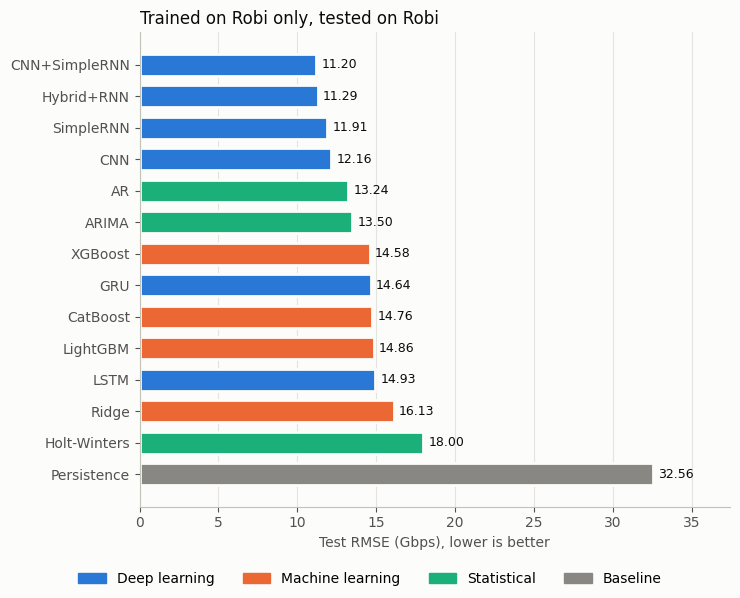

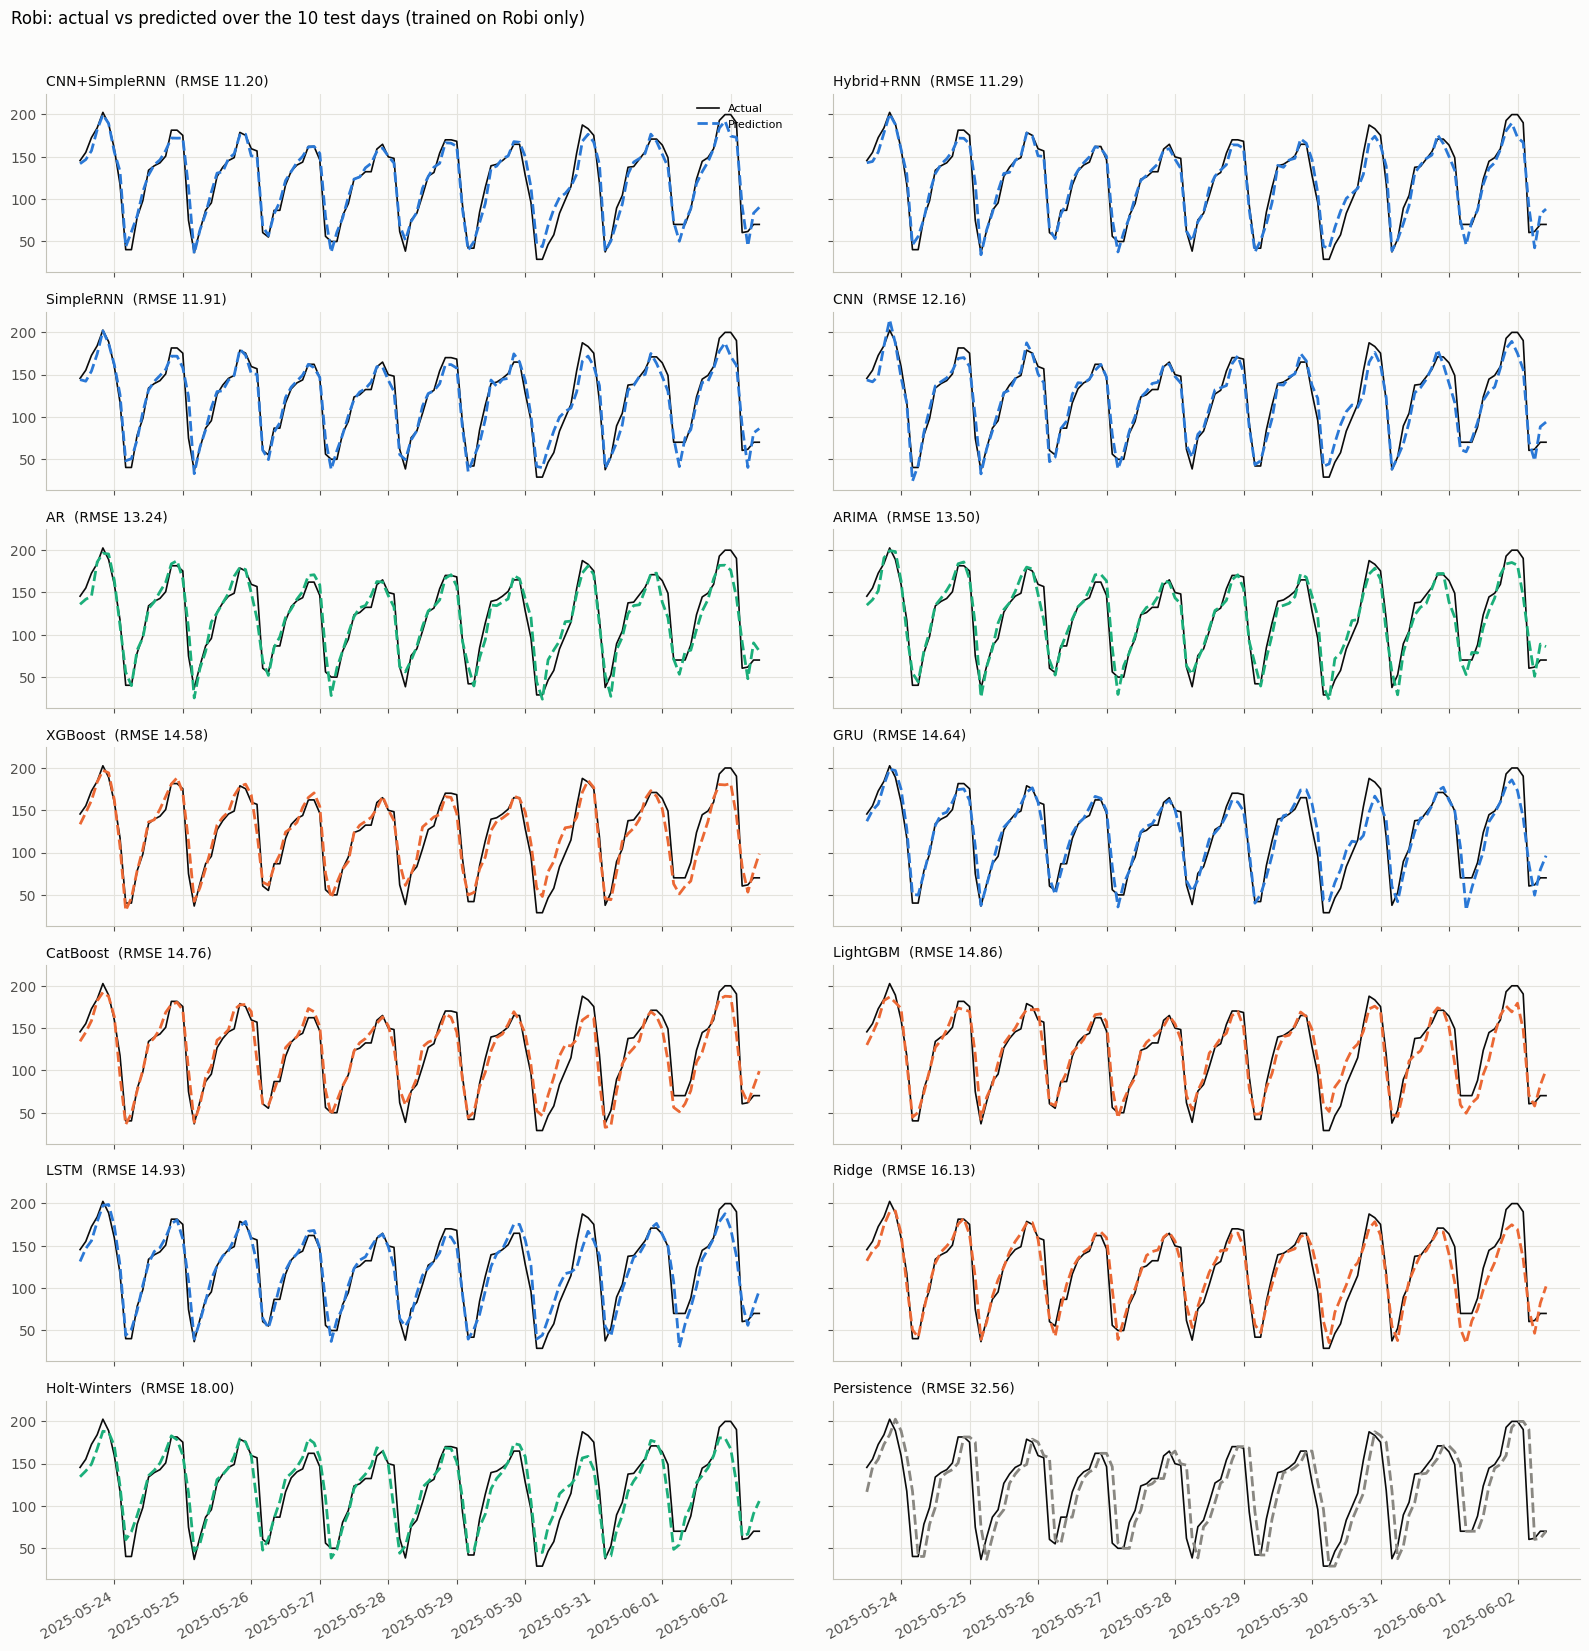

In [21]:
family_colors = {'Deep learning': '#2a78d6', 'Machine learning': '#eb6834',
                 'Statistical': '#1baf7a', 'Baseline': '#898781'}
plt.rcParams.update({'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'axes.edgecolor': '#c3c2b7',
                     'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
                     'axes.spines.top': False, 'axes.spines.right': False})

fig, axes = plt.subplots(1, len(operators), figsize=(7.5 * len(operators), 6), squeeze=False)
for ax, operator in zip(axes[0], operators):
    part = test_metrics[test_metrics.operator.eq(operator)].sort_values('RMSE_Gbps')
    colors = [family_colors[f] for f in part.family]
    ax.barh(part.model, part.RMSE_Gbps, color=colors, height=0.7, edgecolor='#fcfcfb', linewidth=2)
    ax.invert_yaxis()
    for i, value in enumerate(part.RMSE_Gbps):
        ax.text(value + part.RMSE_Gbps.max() * 0.01, i, f'{value:.2f}', va='center', color='#0b0b0b', fontsize=9)
    ax.set_xlim(0, part.RMSE_Gbps.max() * 1.15)
    ax.set_xlabel('Test RMSE (Gbps), lower is better')
    ax.set_title(f'Trained on {train_label}, tested on {operator}', color='#0b0b0b', loc='left')
    ax.grid(axis='x', color='#e4e3dd', linewidth=0.8)
    ax.set_axisbelow(True)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in family_colors.values()]
fig.legend(handles, family_colors.keys(), loc='lower center', ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(output_dir / 'test_RMSE_by_model.png', dpi=150)
plt.show()

for operator in operators:
    part = test_predictions[test_predictions.operator.eq(operator)]
    ranked = test_metrics[test_metrics.operator.eq(operator)].set_index('model').RMSE_Gbps
    names = ranked.sort_values().index.tolist()
    rows_needed = int(np.ceil(len(names) / 2))
    fig, axes = plt.subplots(rows_needed, 2, figsize=(16, 2.4 * rows_needed), sharex=True, sharey=True)
    for ax, name in zip(axes.ravel(), names):
        one = part[part.model.eq(name)].sort_values('Timestamp')
        ax.plot(one.Timestamp, one.actual_Gbps, color='#0b0b0b', linewidth=1.2, label='Actual')
        ax.plot(one.Timestamp, one.predicted_Gbps, color=family_colors[family[name]], linewidth=2,
                linestyle='--', label='Prediction')
        ax.set_title(f'{name}  (RMSE {ranked[name]:.2f})', fontsize=10, loc='left', color='#0b0b0b')
        ax.grid(color='#e4e3dd', linewidth=0.8)
    for ax in axes.ravel()[len(names):]:
        ax.axis('off')
    axes.ravel()[0].legend(loc='upper right', fontsize=8, frameon=False)
    fig.suptitle(f'{operator}: actual vs predicted over the 10 test days (trained on {train_label})', x=0.01, ha='left')
    fig.autofmt_xdate()
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig.savefig(output_dir / f'{operator}_test_forecasts.png', dpi=130)
    plt.show()

## 17. Forecast and capacity-allocation evaluation


In [22]:
slot_hours = float(interval / pd.Timedelta(hours=1))
assert slot_hours > 0
forecast_snapshot = test_predictions.copy(deep=True)
allocation_slot_frames, allocation_metric_rows, forecast_metric_rows = [], [], []

def conditional_mean(values):
    # No applicable slots is undefined, rather than a fabricated zero average.
    return float(np.mean(values)) if len(values) else np.nan

for key, group in test_predictions.groupby(['operator', 'model'], sort=True):
    group = group.sort_values('Timestamp').reset_index(drop=True)
    observed = group.actual_Gbps.to_numpy(dtype=float)
    forecast = group.predicted_Gbps.to_numpy(dtype=float)
    assert len(group) == 120
    assert np.isfinite(observed).all() and np.isfinite(forecast).all()
    assert (observed >= 0).all() and (group.Timestamp >= test_start).all()
    margin = allocation_margins[key]
    baseline_capacity = np.maximum(0.0, forecast)
    buffered_capacity = baseline_capacity + margin
    assert (buffered_capacity >= baseline_capacity).all()

    slots = group[['Timestamp', 'operator', 'model', 'actual_Gbps', 'predicted_Gbps']].copy()
    slots['baseline_capacity_Gbps'] = baseline_capacity
    slots['margin_Gbps'] = margin
    slots['allocated_capacity_Gbps'] = buffered_capacity
    low_offset, high_offset = diagnostic_band_offsets[key]
    slots['diagnostic_band_lower_Gbps'] = np.maximum(0.0, forecast + low_offset)
    slots['diagnostic_band_upper_Gbps'] = np.maximum(0.0, forecast + high_offset)

    for policy_name, capacity, prefix in [
        ('Forecast only', baseline_capacity, 'baseline'),
        ('With margin', buffered_capacity, 'buffered'),
    ]:
        gap = observed - capacity
        under, over, equal = gap > 0, gap < 0, gap == 0
        shortfall, excess = np.maximum(gap, 0), np.maximum(-gap, 0)
        assert int(under.sum() + over.sum() + equal.sum()) == len(group)
        slots[f'{prefix}_under'] = under
        slots[f'{prefix}_over'] = over
        slots[f'{prefix}_shortfall_Gbps'] = shortfall
        slots[f'{prefix}_excess_Gbps'] = excess
        allocation_metric_rows.append({
            'operator': key[0], 'model': key[1], 'policy': policy_name,
            'n': len(group), 'margin_Gbps': margin if prefix == 'buffered' else 0.0,
            'under_count': int(under.sum()), 'under_pct': float(under.mean() * 100),
            'over_count': int(over.sum()), 'over_pct': float(over.mean() * 100),
            'equal_count': int(equal.sum()), 'equal_pct': float(equal.mean() * 100),
            'avg_shortfall_when_under_Gbps': conditional_mean(shortfall[under]),
            'avg_excess_when_over_Gbps': conditional_mean(excess[over]),
            'total_shortfall_Gbps_h': float(shortfall.sum() * slot_hours),
            'total_excess_Gbps_h': float(excess.sum() * slot_hours),
            'mean_allocated_capacity_Gbps': float(capacity.mean()),
        })
    assert np.all(slots.buffered_shortfall_Gbps <= slots.baseline_shortfall_Gbps + 1e-9)
    assert np.all(slots.buffered_excess_Gbps + 1e-9 >= slots.baseline_excess_Gbps)
    allocation_slot_frames.append(slots)

    error = observed - forecast
    positive = observed > 0
    percentage_error = np.abs(error[positive]) / observed[positive] * 100
    centered_sum = float(np.sum((observed - observed.mean()) ** 2))
    lower = slots.diagnostic_band_lower_Gbps.to_numpy()
    upper = slots.diagnostic_band_upper_Gbps.to_numpy()
    forecast_metric_rows.append({
        'operator': key[0], 'model': key[1], 'n': len(group),
        'RMSE_Gbps': float(np.sqrt(np.mean(error ** 2))),
        'MAE_Gbps': float(np.mean(np.abs(error))),
        'MAPE_pct_positive_actual': conditional_mean(percentage_error),
        'percentage_metric_n': int(positive.sum()),
        'zero_actual_n': int((~positive).sum()),
        'R2': 1 - float(np.sum(error ** 2)) / centered_sum if centered_sum > 0 else np.nan,
        'within_tolerance_pct_positive_actual': (
            float(np.mean(percentage_error <= forecast_tolerance_pct) * 100)
            if len(percentage_error) else np.nan
        ),
        'forecast_underprediction_pct': float(np.mean(forecast < observed) * 100),
        'forecast_overprediction_pct': float(np.mean(forecast > observed) * 100),
        'negative_forecast_n': int(np.sum(forecast < 0)),
        'nominal_band_pct': diagnostic_band_level * 100,
        'observed_band_coverage_pct': float(np.mean((observed >= lower) & (observed <= upper)) * 100),
        'avg_band_width_Gbps': float(np.mean(upper - lower)),
    })

allocation_predictions = pd.concat(allocation_slot_frames, ignore_index=True)
allocation_metrics = pd.DataFrame(allocation_metric_rows)
forecast_diagnostics = pd.DataFrame(forecast_metric_rows)
pd.testing.assert_frame_equal(test_predictions, forecast_snapshot)
assert not allocation_predictions.duplicated(['Timestamp', 'operator', 'model']).any()
np.testing.assert_allclose(
    forecast_diagnostics.set_index(['operator', 'model']).RMSE_Gbps.sort_index(),
    test_metrics.set_index(['operator', 'model']).RMSE_Gbps.sort_index(),
)

allocation_comparisons = {}
for operator in operators:
    forecast_table = forecast_diagnostics[forecast_diagnostics.operator.eq(operator)].sort_values('RMSE_Gbps')
    order = forecast_table.model.tolist()
    own_metrics = allocation_metrics[allocation_metrics.operator.eq(operator)]
    before = own_metrics[own_metrics.policy.eq('Forecast only')].set_index('model').loc[order]
    after = own_metrics[own_metrics.policy.eq('With margin')].set_index('model').loc[order]
    comparison = pd.DataFrame({
        'Margin (Gbps)': after.margin_Gbps,
        'Under before (%)': before.under_pct,
        'Under after (%)': after.under_pct,
        'Shortfall before (Gbps·h)': before.total_shortfall_Gbps_h,
        'Shortfall after (Gbps·h)': after.total_shortfall_Gbps_h,
        'Excess before (Gbps·h)': before.total_excess_Gbps_h,
        'Excess after (Gbps·h)': after.total_excess_Gbps_h,
    })
    allocation_comparisons[operator] = comparison
    print(f'{operator}: unchanged forecast errors on 120 historical holdout slots')
    display(forecast_table.set_index('model')[
        ['RMSE_Gbps', 'MAE_Gbps', 'MAPE_pct_positive_actual', 'percentage_metric_n',
         'R2', 'observed_band_coverage_pct']
    ].round(3))
    print(f'{operator}: simulated capacity, forecast only versus frozen validation margin')
    display(comparison.round(3))

allocation_predictions.to_csv(output_dir / 'allocation_predictions.csv', index=False)
allocation_metrics.to_csv(output_dir / 'allocation_metrics.csv', index=False)
forecast_diagnostics.to_csv(output_dir / 'forecast_diagnostics.csv', index=False)
for operator, table in allocation_comparisons.items():
    table.to_csv(output_dir / f'{operator}_allocation_comparison.csv')


Robi: unchanged forecast errors on 120 historical holdout slots


,RMSE_Gbps,MAE_Gbps,MAPE_pct_positive_actual,percentage_metric_n,R2,observed_band_coverage_pct
model,,,,,,
CNN+SimpleRNN,11.196,8.155,9.659,120,0.943,82.500
Hybrid+RNN,11.295,8.262,9.452,120,0.942,85.000
SimpleRNN,11.906,8.824,9.720,120,0.936,85.833
CNN,12.161,9.116,9.819,120,0.933,87.500
AR,13.245,9.884,11.178,120,0.921,82.500
ARIMA,13.500,10.279,11.505,120,0.917,86.667
XGBoost,14.580,11.154,12.769,120,0.904,84.167
GRU,14.644,10.853,12.098,120,0.903,83.333
CatBoost,14.760,11.039,11.881,120,0.901,85.000


Robi: simulated capacity, forecast only versus frozen validation margin


,Margin (Gbps),Under before (%),Under after (%),Shortfall before (Gbps·h),Shortfall after (Gbps·h),Excess before (Gbps·h),Excess after (Gbps·h)
model,,,,,,,
CNN+SimpleRNN,20.144,48.333,1.667,879.671,20.413,1077.455,5052.751
Hybrid+RNN,21.467,54.167,3.333,1030.288,27.220,952.554,5101.575
SimpleRNN,23.437,54.167,3.333,1235.525,35.288,882.274,5306.959
CNN,24.091,53.333,5.000,1232.038,47.019,955.819,5552.677
AR,22.842,51.667,5.833,1275.598,109.379,1096.562,5412.460
ARIMA,20.428,49.167,5.833,1253.094,120.901,1213.889,4984.304
XGBoost,27.330,50.000,3.333,1270.103,71.995,1406.814,6768.020
GRU,24.992,48.333,5.833,1297.100,139.151,1307.660,6147.906
CatBoost,27.678,53.333,4.167,1419.334,107.212,1229.918,6560.490


### Allocation trade-off charts


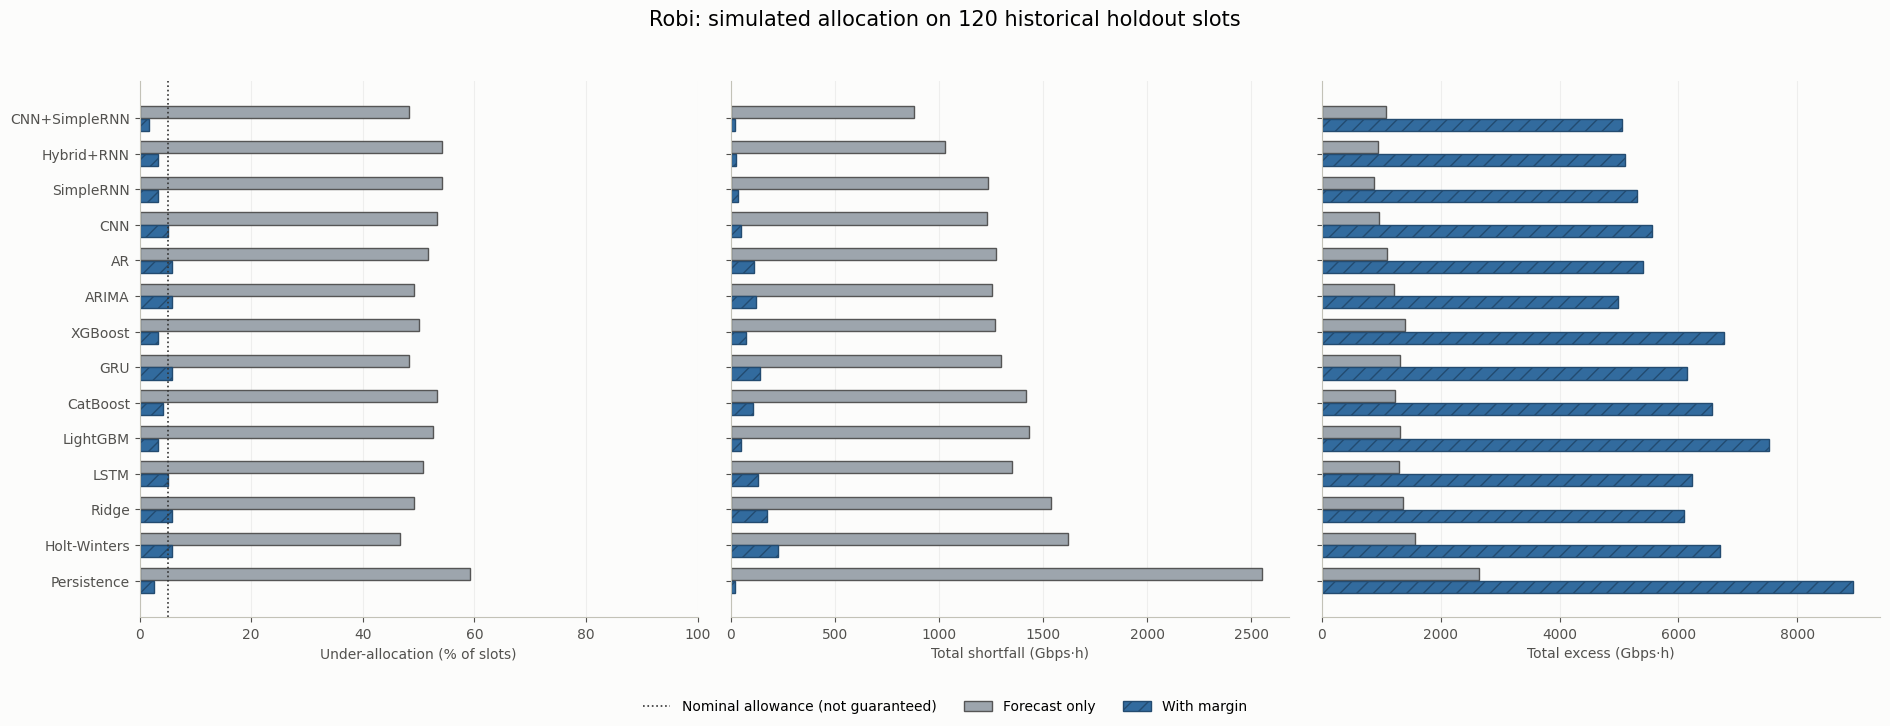

In [23]:
allocation_plot_paths = []
for operator in operators:
    own = allocation_metrics[allocation_metrics.operator.eq(operator)]
    order = allocation_comparisons[operator].index.tolist()
    before = own[own.policy.eq('Forecast only')].set_index('model').loc[order]
    after = own[own.policy.eq('With margin')].set_index('model').loc[order]
    positions = np.arange(len(order))
    fig, axes = plt.subplots(1, 3, figsize=(19, max(7, len(order) * 0.52)), sharey=True)
    specs = [
        ('under_pct', 'Under-allocation (% of slots)'),
        ('total_shortfall_Gbps_h', 'Total shortfall (Gbps·h)'),
        ('total_excess_Gbps_h', 'Total excess (Gbps·h)'),
    ]
    for ax, (metric, label) in zip(axes, specs):
        ax.barh(positions - 0.18, before[metric], height=0.34,
                color='#9da5ad', edgecolor='#555555', label='Forecast only')
        ax.barh(positions + 0.18, after[metric], height=0.34,
                color='#326b9e', edgecolor='#234b70', hatch='//', label='With margin')
        ax.set_xlabel(label)
        ax.set_xlim(left=0)
        ax.set_yticks(positions)
        ax.grid(axis='x', alpha=0.18)
        ax.set_axisbelow(True)
    axes[0].set_yticklabels(order)
    axes[0].invert_yaxis()
    axes[0].set_xlim(0, 100)
    axes[0].axvline((1 - allocation_policy_config['quantile']) * 100,
                    color='#333333', linestyle=':', linewidth=1.2,
                    label='Nominal allowance (not guaranteed)')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
    fig.suptitle(f'{operator}: simulated allocation on 120 historical holdout slots', fontsize=15)
    fig.tight_layout(rect=[0, 0.065, 1, 0.95])
    plot_path = output_dir / f'{operator}_allocation_tradeoff.png'
    fig.savefig(plot_path, dpi=150, bbox_inches='tight')
    allocation_plot_paths.append(plot_path)
    plt.show()
    plt.close(fig)


## 18. Save all results and create the ZIP


In [24]:
validation_for_allocation.to_csv(output_dir / 'validation_predictions.csv', index=False)
test_predictions.to_csv(output_dir / 'test_predictions.csv', index=False)
train_predictions.to_csv(output_dir / 'train_predictions.csv', index=False)
test_metrics.to_csv(output_dir / 'test_metrics.csv', index=False)
validation_metrics.to_csv(output_dir / 'validation_metrics.csv', index=False)
fit_check.to_csv(output_dir / 'train_validation_test_rmse.csv', index=False)
seed_results.to_csv(output_dir / 'neural_seed_results.csv', index=False)
same_data.to_csv(output_dir / 'data_split.csv', index=False)
summary.to_csv(output_dir / 'summary.csv')

versions = {}
for package in ['numpy', 'pandas', 'scikit-learn', 'lightgbm', 'xgboost', 'catboost', 'statsmodels']:
    try:
        versions[package] = version(package)
    except Exception:
        versions[package] = 'unknown'
versions['tensorflow'] = tf.__version__
manifest = {'source_workbook_sha256': {op: EMBEDDED_WORKBOOKS[op]['sha256'] for op in operators}, 'mode': mode, 'operators': operators, 'sources': sources,
            'validation_start': str(valid_start), 'test_start': str(test_start),
            'rows_per_operator': {'train': int((train_mask & meta.operator.eq(operators[0]).to_numpy()).sum()),
                                  'validation': 120, 'test': 120},
            'lags': lags, 'rolling_windows': roll_windows, 'lookback': lookback, 'features': feature_names,
            'seeds': seeds, 'tuning_seeds': tuning_seeds, 'max_epochs': max_epochs, 'patience': patience,
            'selected_settings': selected, 'target_scalers': target_scalers, 'versions': versions}
(output_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2, default=str))


manifest['allocation_policy'] = allocation_policy_config
manifest['allocation_policy_sha256'] = allocation_policy_sha256
manifest['allocation_calibration'] = allocation_policy_records
manifest['execution_note'] = 'Metrics in this folder are produced by this execution.'
manifest['statistical_reference_sources'] = globals().get('statistical_reference_sources', {})
(output_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2, default=str))

# Archive only outputs produced by this run, after allocation tables and charts.
export_names = [
    'test_predictions.csv', 'train_predictions.csv', 'test_metrics.csv',
    'validation_predictions.csv', 'validation_metrics.csv', 'train_validation_test_rmse.csv',
    'neural_seed_results.csv', 'data_split.csv', 'summary.csv',
    'tuning_results.csv', 'selected_settings.json', 'run_manifest.json',
    'test_RMSE_by_model.png', 'allocation_calibration.csv', 'allocation_policy.json',
    'allocation_predictions.csv', 'allocation_metrics.csv', 'forecast_diagnostics.csv',
]
for operator in operators:
    export_names += [f'{operator}_test_forecasts.png',
                     f'{operator}_allocation_comparison.csv',
                     f'{operator}_allocation_tradeoff.png']
if mode == 'Combined' and len(comparison_rows) > 0:
    export_names.append('single_vs_ensembled.csv')
archive = output_root / f'{run_name}_results.zip'
with zipfile.ZipFile(archive, 'w', zipfile.ZIP_DEFLATED) as z:
    for name in export_names:
        path = output_dir / name
        assert path.is_file(), f'Missing current-run export: {path}'
        z.write(path, path.name)
print('Saved forecasts and allocation results to', output_dir)
print('Download everything as one file:', archive)


Saved forecasts and allocation results to /kaggle/working/final_model_results/Robi_only
Download everything as one file: /kaggle/working/final_model_results/Robi_only_results.zip
